# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from scipy.interpolate import interp1d

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    #model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    #model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse

In [3]:
def initialize_pose(model, data_i = 0):
    mj_data = mujoco.MjData(model)
    mj_data.qpos = qpos_data.iloc[data_i][joint_names].values
    mujoco.mj_forward(model, mj_data)

    return mj_data

In [22]:
def error(goal_qpos, current_qpos, current_qvel):
    goal_qpos = qpos_data.iloc[next_i][interest_joint_names].values
    error_q = np.zeros_like(goal_qpos)
    error_q[interest_joint_ids] = goal_qpos - current_qpos[interest_joint_ids]
    
    error_v = np.zeros_like(goal_qpos)
    error_v[interest_joint_ids] = 0 - current_qvel[interest_joint_ids]
    return error_q, error_v

In [23]:
def downsampling(df):
    df = df.copy()
    x = df["times"].values
    y = df.drop(columns = ["times"]).values
    
    new_times = np.arange(x.min(), x.max() + 1e-7, 0.0001)
    f = interp1d(x, y, kind = "cubic", axis = 0, fill_value = "extrapolate")
    new_y = f(new_times)
    new_df = pd.DataFrame(new_y, columns = df.columns.drop("times"))
    new_df.insert(0, "times", new_times)
    return new_df

# Params

In [24]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"

simulation_interval = 0.0001

# PD control
kp = 500.0 # Stiffness
kv = 50.0 # Damping

# Load data

In [25]:
qpos_path = os.path.join(f"/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/IK_files/trial1_IK_qpos.csv")
qpos_data = pd.read_csv(qpos_path, index_col = 0)
qpos_data = downsampling(qpos_data)

sampling_freq = qpos_data.times[1] - qpos_data.times[0]
n_times = 10

# Initialize model

In [26]:
pd_model = mujoco.MjModel.from_xml_path(model_path)
pd_model.opt.timestep = simulation_interval

mj_model = mujoco.MjModel.from_xml_path(model_path)
mj_model.opt.timestep = simulation_interval

# Model constants
joint_names = [mujoco.mj_id2name(pd_model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(pd_model.njnt)]
n_joint = len(joint_names)

# Joint indexing
interest_joint_names = joint_names
interest_joint_map = {}
for joint_name in interest_joint_names:
    jnt_id = pd_model.joint(joint_name).id
    qpos_idx = pd_model.jnt_qposadr[jnt_id]
    dof_idx = pd_model.jnt_dofadr[jnt_id]
    
    interest_joint_map[joint_name] = {
        "joint_id" : jnt_id,
        "qposadr" : qpos_idx,
        "dofadr" : dof_idx,
    }

interest_joint_ids = [interest_joint_map[name]["joint_id"] for name in interest_joint_names]
interest_joint_ids = np.array(interest_joint_ids)

# Initialize pose
pd_data = initialize_pose(pd_model)
mj_data = initialize_pose(mj_model)

# Renderer

In [27]:
# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

pd_renderer = renderer(pd_model, pd_data)
mj_renderer = renderer(mj_model, mj_data)

NameError: name 'scene_option' is not defined

# Simulation

In [18]:
def result_dummy(renderer, n_times, n_joint, joint_names):
    pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)
    
    qpos_traj = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
    qpos_traj.columns = ["time"] + joint_names
    
    qforces = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
    qforces.columns = ["time"] + joint_names
    
    qerrors = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
    qerrors.columns = ["time"] + joint_names
    
    return pixels, qpos_traj, qforces, qerrors

In [19]:
start_i = 20
next_i = start_i + 1

# Initialize pose
pd_data = initialize_pose(pd_model, data_i = start_i)
mj_data = initialize_pose(mj_model, data_i = start_i)

# Simulation Constants
times = np.arange(n_times) * pd_model.opt.timestep

# Result dummy
pd_pixels, pd_qpos_traj, pd_qforces, pd_qerrors = result_dummy(pd_renderer, n_times, n_joint, joint_names)
mj_pixels, mj_qpos_traj, mj_qforces, mj_qerrors = result_dummy(mj_renderer, n_times, n_joint, joint_names)

# Simulation
for time_i in tqdm(range(n_times)):
    time = times[time_i]
    
    # Current
    pd_current_qpos, pd_current_qvel = pd_data.qpos.copy(), pd_data.qvel.copy()
    mj_current_qpos, mj_current_qvel = mj_data.qpos.copy(), mj_data.qvel.copy()
    
    # PD Control
    goal_qpos = qpos_data.iloc[next_i][interest_joint_names].values
    pd_error_q, pd_error_v = error(goal_qpos = goal_qpos, current_qpos = pd_current_qpos, current_qvel = pd_current_qvel)
    pd_tau_all = kp * pd_error_q + kv * pd_error_v

    pd_data.qfrc_applied[:] = pd_tau_all
    mujoco.mj_step(pd_model, pd_data)
    
    pd_qpos_traj.iloc[time_i] = np.hstack([time, pd_current_qpos])
    pd_qerrors.iloc[time_i] = np.hstack([time, pd_error_q])
    pd_qforces.iloc[time_i] = np.hstack([time, pd_tau_all])

    # MJ inverse
    mj_error_q, mj_error_v = error(goal_qpos = goal_qpos, current_qpos = mj_current_qpos, current_qvel = mj_current_qvel)
    mj_tau_all = get_qfrc(mj_model, mj_data, goal_qpos)

    mj_data.qfrc_applied[:] = mj_tau_all
    mujoco.mj_step(mj_model, mj_data)

    mj_qpos_traj.iloc[time_i] = np.hstack([time, mj_current_qpos])
    mj_qerrors.iloc[time_i] = np.hstack([time, mj_error_q])
    mj_qforces.iloc[time_i] = np.hstack([time, mj_tau_all])
    
    # Rendering
    pd_renderer.update_scene(pd_data, camera = camera, scene_option = scene_option)
    pd_pixels[time_i] = pd_renderer.render()
    
    mj_renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    mj_pixels[time_i] = mj_renderer.render()

  0%|          | 0/10 [00:00<?, ?it/s]


NameError: name 'scene_option' is not defined

# Error plot

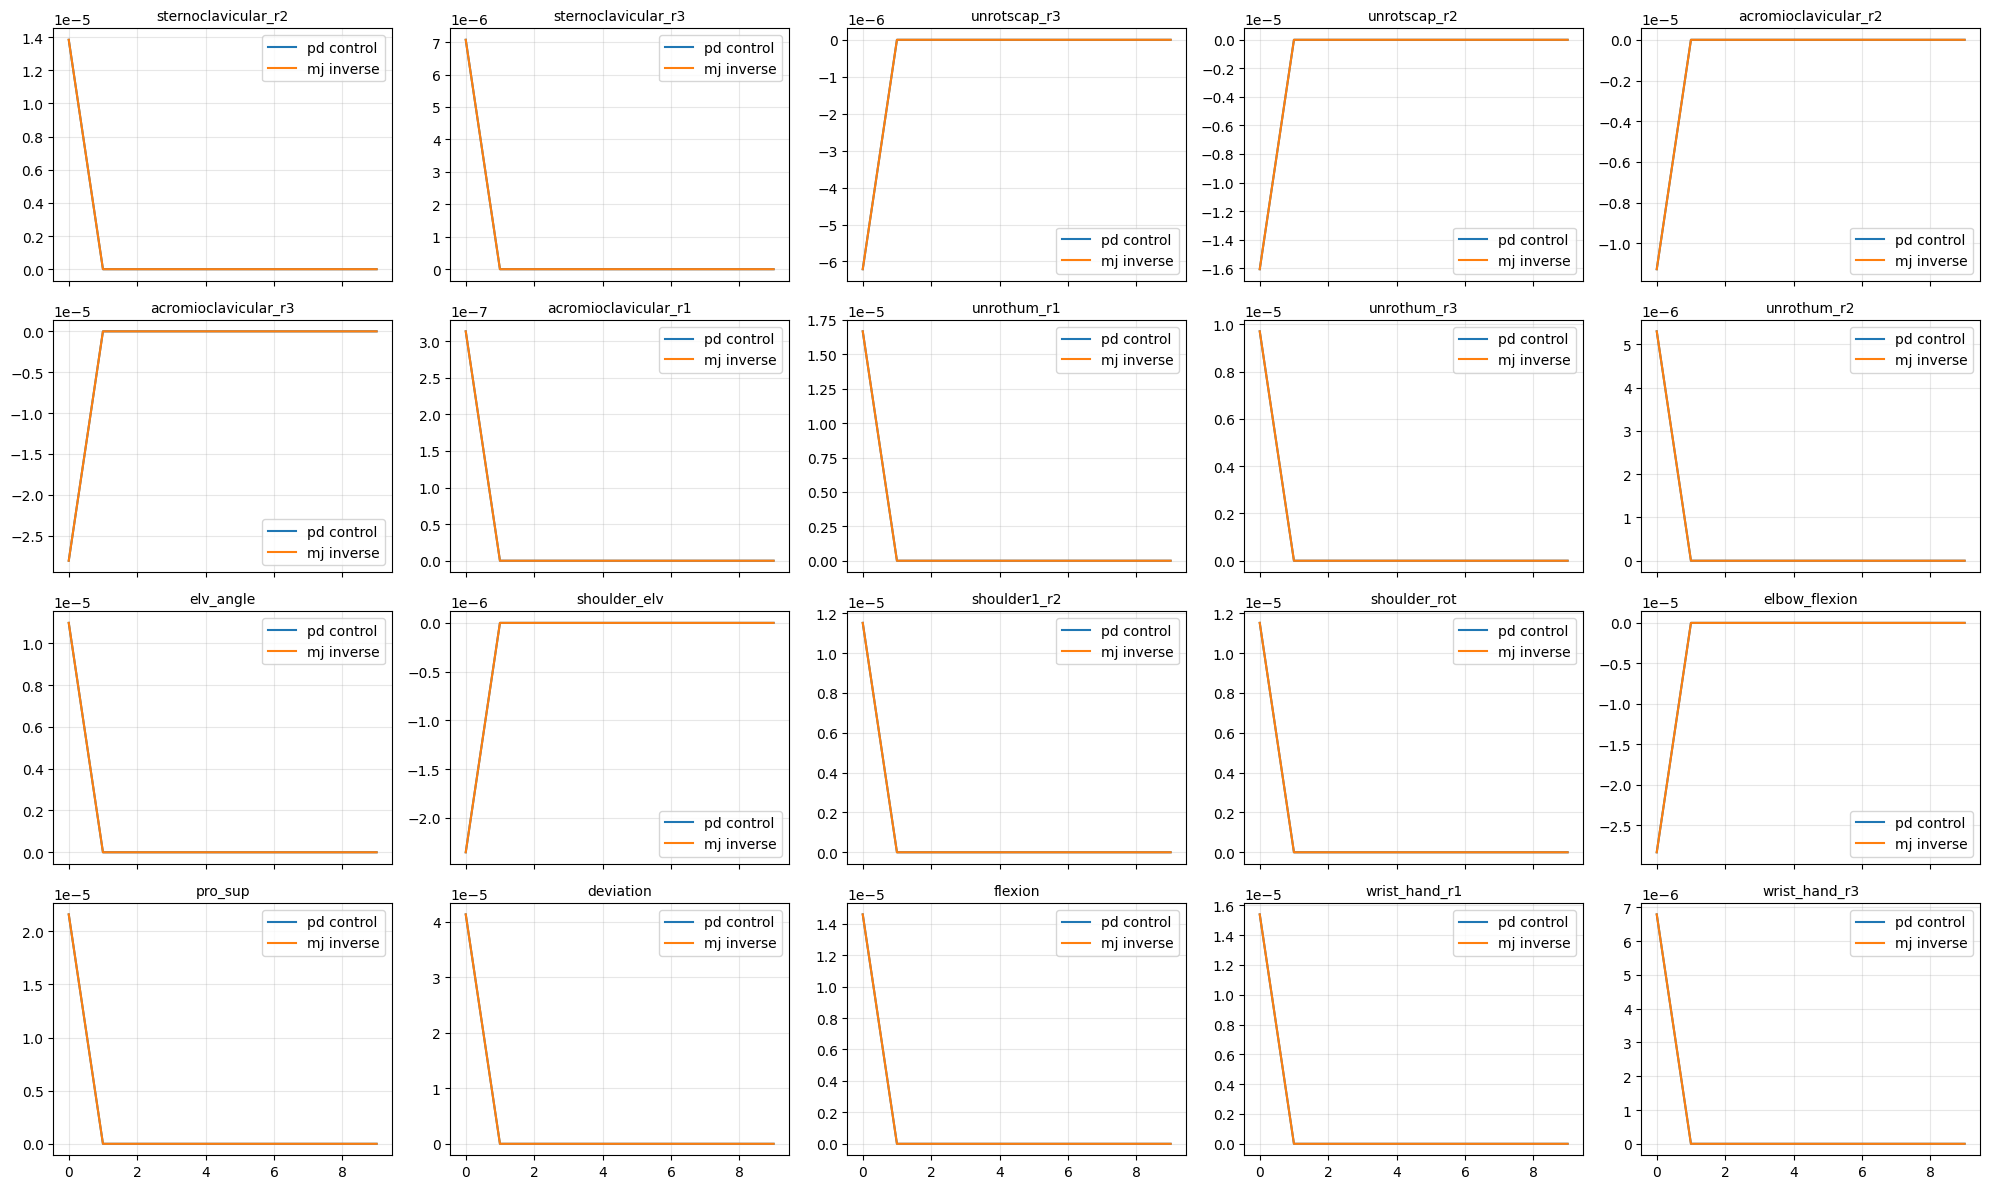

In [20]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(pd_qerrors[joint_name], lw=1.5, label = "pd control")
    ax.plot(mj_qerrors[joint_name], lw=1.5, label = "mj inverse")
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend()
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Force plot

In [ ]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(pd_qforces[joint_name], lw=1.5, label = "pd control")
    ax.plot(mj_qforces[joint_name], lw=1.5, label = "mj inverse")
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend()
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()